In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
from io import StringIO

import importlib
import requests

# Funciones auxiliares
import auxfun
importlib.reload(auxfun)

<module 'auxfun' from 'c:\\Users\\Deportivo Estadio\\Desktop\\Master Quant\\Gestión de activos\\Trabajo gestión cuantitativa\\Trabajo_gestion_cuantitativa\\Trabajo_gestion_cuantitativa\\Monitoring\\auxfun.py'>

## Desagregación por activos
El efecto selección mide si elegimos activos que lo hicieron mejor que el BMK, y el efecto peso mide si además les diste el peso correcto. La suma de ambos es el alpha total respecto al BMK equiponderado.

In [18]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

universo_tickers = get_eurostoxx50_tickers()

df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
fechas_op = sorted(df["fecha"].unique())
tabla_pnl = auxfun.analisis_todas_semanas(df, universo_tickers)

display(tabla_pnl.style.format({
    "P&L neto (€)": "{:,.0f}",
    "P&L bruto (€)": "{:,.0f}",
    "Efecto costes (€)": "{:,.0f}",
    "Valor final posición (€)": "{:,.0f}",
    "Flujo neto (€)": "{:,.0f}",
    "Diferencia vs NAV (€)": "{:,.2f}",
}))

,P&L neto (€),P&L bruto (€),Efecto costes (€),Valor final posición (€),Flujo neto (€),Diferencia vs NAV (€)
Ticker,,,,,,
IFX.DE,"181,572","182,410",-839,"626,010","-444,438",nan
INGA.AS,"93,853","94,654",-801,0,"93,853",nan
SAN.MC,"73,635","74,377",-741,"359,281","-285,645",nan
ENR.DE,"68,156","70,356","-2,200","1,520,459","-1,452,303",nan
SGO.PA,"48,459","49,271",-812,0,"48,459",nan
SAF.PA,"47,270","48,070",-800,0,"47,270",nan
ASML.AS,"45,400","47,323","-1,922","1,492,410","-1,447,009",nan
RHM.DE,"36,799","38,265","-1,467","303,761","-266,963",nan
ENI.MI,"29,791","30,956","-1,165","1,526,105","-1,496,314",nan


In [19]:
tabla_aciertos = auxfun.generar_tabla_aciertos(df, universo_tickers)
display(tabla_aciertos)

Periodo: 2026-03-12 → 2026-03-20 | Ret. Cartera: -5.44% | Hit rate: 20% | BMK STOXX: -4.31% | BMK EW: -4.31%
Periodo: 2026-03-20 → 2026-03-27 | Ret. Cartera: -0.37% | Hit rate: 40% | BMK STOXX: 0.08% | BMK EW: 0.19%
Periodo: 2026-03-27 → 2026-04-03 | Ret. Cartera: 3.39% | Hit rate: 13% | BMK STOXX: 3.40% | BMK EW: 3.66%
Periodo: 2026-04-03 → 2026-04-10 | Ret. Cartera: 4.28% | Hit rate: 60% | BMK STOXX: 4.10% | BMK EW: 3.59%
Periodo: 2026-04-10 → 2026-04-17 | Ret. Cartera: 0.23% | Hit rate: 44% | BMK STOXX: 2.22% | BMK EW: 3.06%
Periodo: 2026-04-17 → 2026-04-24 | Ret. Cartera: -0.38% | Hit rate: 26% | BMK STOXX: -2.88% | BMK EW: -3.23%
Periodo: 2026-04-24 → 2026-05-01 | Ret. Cartera: 0.47% | Hit rate: 40% | BMK STOXX: -0.03% | BMK EW: 0.37%


,2026-03-12→2026-03-20,2026-03-20→2026-03-27,2026-03-27→2026-04-03,2026-04-03→2026-04-10,2026-04-10→2026-04-17,2026-04-17→2026-04-24,2026-04-24→2026-05-01
ADS.DE,❌,❌,❌,❌,✅,❌,✅
ADYEN.AS,❌,❌,❌,❌,✅,❌,❌
AIR.PA,❌,-,-,-,-,-,-
ARGX.BR,❌,✅,-,-,-,-,-
ASML.AS,❌,✅,❌,✅,❌,✅,❌
BAYN.DE,✅,❌,❌,❌,❌,❌,❌
BBVA.MC,✅,-,-,✅,❌,❌,✅
DBK.DE,❌,❌,❌,✅,❌,❌,❌
EL.PA,❌,❌,-,-,-,-,-
ENI.MI,-,✅,❌,❌,❌,✅,✅


In [20]:
tabla_resumen = auxfun.resumen_por_activo(df, universo_tickers)
display(tabla_resumen)

Periodo: 2026-03-12 → 2026-03-20 | Ret. Cartera: -5.44% | Hit rate: 20% | BMK STOXX: -4.31% | BMK EW: -4.31%
Periodo: 2026-03-20 → 2026-03-27 | Ret. Cartera: -0.37% | Hit rate: 40% | BMK STOXX: 0.08% | BMK EW: 0.19%
Periodo: 2026-03-27 → 2026-04-03 | Ret. Cartera: 3.39% | Hit rate: 13% | BMK STOXX: 3.40% | BMK EW: 3.66%
Periodo: 2026-04-03 → 2026-04-10 | Ret. Cartera: 4.28% | Hit rate: 60% | BMK STOXX: 4.10% | BMK EW: 3.59%
Periodo: 2026-04-10 → 2026-04-17 | Ret. Cartera: 0.23% | Hit rate: 44% | BMK STOXX: 2.22% | BMK EW: 3.06%
Periodo: 2026-04-17 → 2026-04-24 | Ret. Cartera: -0.38% | Hit rate: 26% | BMK STOXX: -2.88% | BMK EW: -3.23%
Periodo: 2026-04-24 → 2026-05-01 | Ret. Cartera: 0.47% | Hit rate: 40% | BMK STOXX: -0.03% | BMK EW: 0.37%


,Ticker,Veces_Seleccionado,Aciertos,Retorno_Promedio,Ranking_Promedio,Hit_Rate
0,IFX.DE,5,4,8.89%,6.2,80%
1,RHM.DE,3,2,4.52%,9.3,67%
2,BBVA.MC,5,3,0.56%,20.4,60%
3,INGA.AS,5,3,3.33%,14.6,60%
4,SAN.MC,5,3,2.38%,19.6,60%
5,ENI.MI,6,3,0.59%,24.0,50%
6,SGO.PA,6,3,2.30%,21.0,50%
7,ARGX.BR,2,1,-0.60%,16.5,50%
8,ASML.AS,7,3,0.61%,26.6,43%
9,ENR.DE,7,3,2.62%,22.3,43%


## Desempeño del modelo y la estrategia

In [21]:
tabla = auxfun.tabla_aciertos_semanales(df, universo_tickers)
display(tabla)

,Periodo,Top 15,Top 30,Top 45,Bottom 5
0,2026-03-12 → 2026-03-20,3/15,4/15,7/15,1/15
1,2026-03-20 → 2026-03-27,6/15,2/15,4/15,3/15
2,2026-03-27 → 2026-04-03,2/15,7/15,5/15,1/15
3,2026-04-03 → 2026-04-10,9/15,0/15,5/15,1/15
4,2026-04-10 → 2026-04-17,7/16,5/16,2/16,2/16
5,2026-04-17 → 2026-04-24,5/19,4/19,8/19,2/19
6,2026-04-24 → 2026-05-01,8/20,4/20,7/20,1/20


In [22]:
scores_por_fecha = auxfun.recuperar_scores_historicos(fechas_op, universo_tickers)
auxfun.analisis_scores(scores_por_fecha, df, universo_tickers)

Rentabilidad media por quintil de score (todas las semanas):


,Retorno
Quintil,
Q1,0.69%
Q2,1.31%
Q3,1.05%
Q4,1.68%
Q5,1.67%



Score medio elegidos vs no elegidos:


,Score
Elegido,
False,0.422
True,0.537


,Fecha,Ticker,Score,Retorno,Elegido,Quintil
0,2026-03-20,ABI.BR,0.381691,-0.002366,False,Q1
1,2026-03-20,AD.AS,0.374396,-0.025948,False,Q1
2,2026-03-20,ADS.DE,0.519630,-0.010861,True,Q4
3,2026-03-20,ADYEN.AS,0.682919,-0.009265,True,Q5
4,2026-03-20,AI.PA,0.297947,0.034083,False,Q1
...,...,...,...,...,...,...
295,2026-04-24,SU.PA,0.405379,-0.026812,False,Q2
296,2026-04-24,TTE.PA,0.412195,0.029740,True,Q2
297,2026-04-24,UCG.MI,0.423341,0.025152,False,Q3
298,2026-04-24,VOW.DE,0.428575,-0.010686,False,Q3


Rentabilidad media por quintil de score (últimas 2 semanas):


,Retorno
Quintil,
Q1,0.09%
Q2,-0.04%
Q3,0.81%
Q4,-1.08%
Q5,2.05%



Score medio elegidos vs no elegidos:


,Score
Elegido,
False,0.405
True,0.526


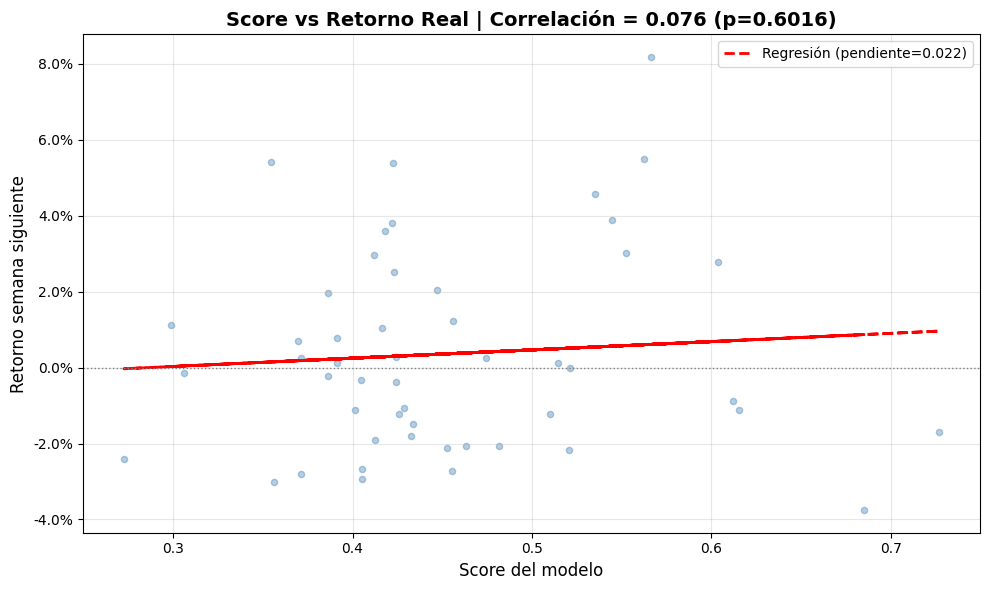


📊 Correlación Score-Retorno: 0.0756
   Significancia (p-value): 0.6016
   Pendiente regresión: 0.0218

   Interpretación:
   ❌ Correlación casi nula → modelo no predice


In [23]:
df_scores = auxfun.analisis_scores(scores_por_fecha, df, universo_tickers, ultimas_n=2)
auxfun.grafico_score_vs_retorno(df_scores)

In [24]:
# auxfun.top_bottom_todas_semanas(df, universo_tickers)